<a href="https://colab.research.google.com/github/Rahul8243/SML/blob/main/SML_lab%5B09%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully!

Number of rows and columns: (569, 32)

First 5 rows:
          id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980    

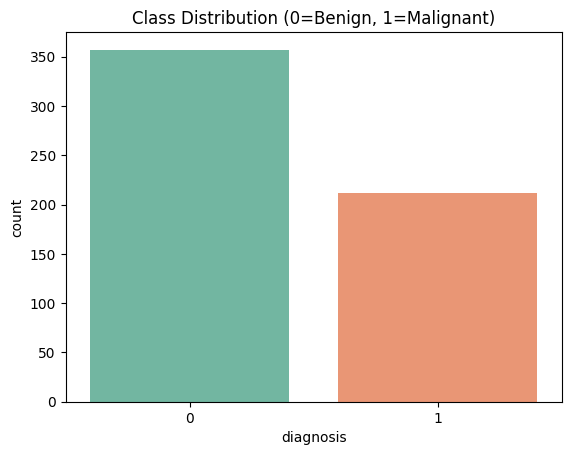

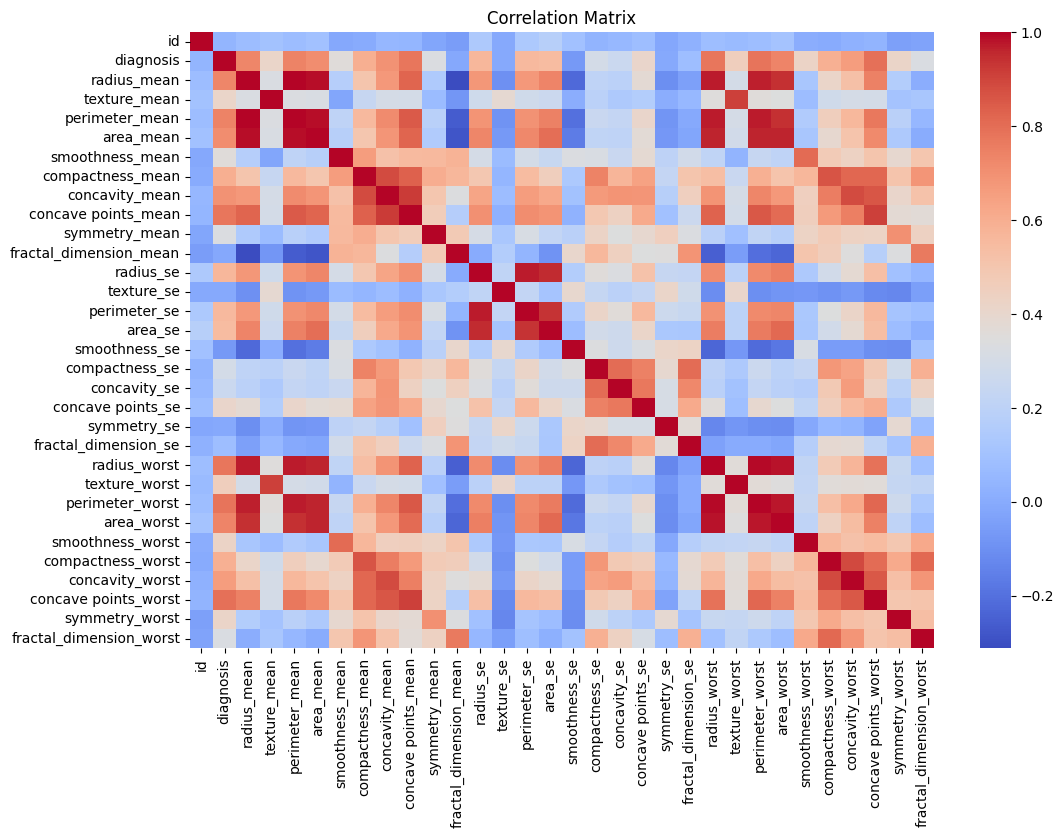

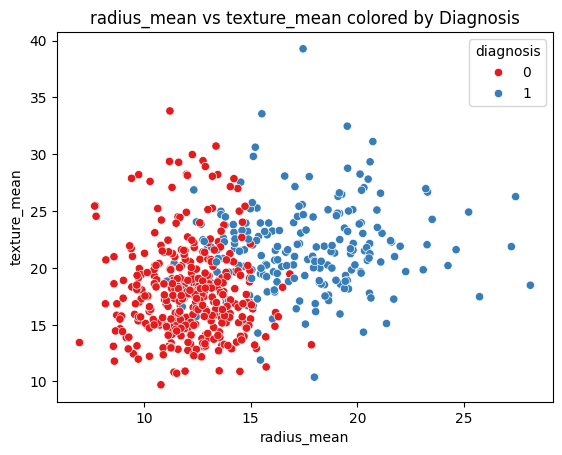


Top 10 features correlated with target:
 ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']

Training set size: (455, 10)
Testing set size: (114, 10)

SVM Model Accuracies:
linear kernel: 0.9561
poly kernel: 0.8860
rbf kernel: 0.9123


/tmp/ipython-input-1823763854.py:123: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kernel', y='Accuracy', data=acc_df, palette="Set2")


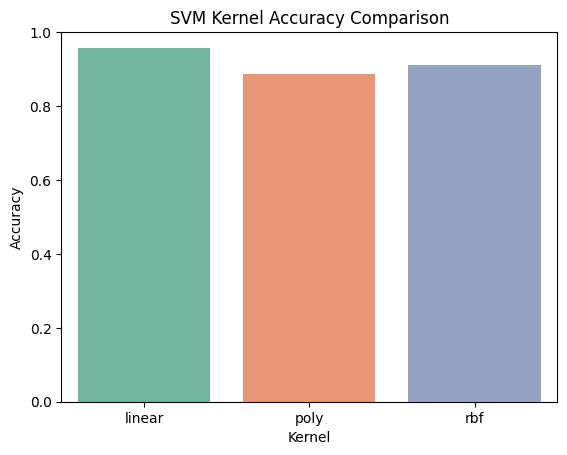

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


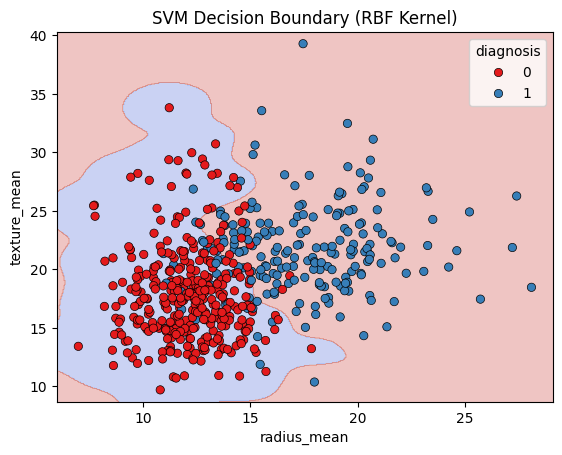


Classification Report for linear kernel:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        72
           1       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114


Classification Report for poly kernel:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        72
           1       1.00      0.69      0.82        42

    accuracy                           0.89       114
   macro avg       0.92      0.85      0.87       114
weighted avg       0.90      0.89      0.88       114


Classification Report for rbf kernel:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        72
           1       1.00      0.76      0.86        42

    accuracy                           0.91       114
   macr

In [2]:
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load Dataset
try:
    df = pd.read_csv("/content/breast-cancer.csv")
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")
    exit()

# Check Dataset Info
print("\nNumber of rows and columns:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# Ensure 'diagnosis' column exists
if 'diagnosis' not in df.columns:
    print("Error: 'diagnosis' column not found.")
    exit()

# Encode target variable
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
if df['diagnosis'].isnull().any():
    print("Error: Unknown values in 'diagnosis' column.")
    exit()

# Q2: Class Distribution
print("\nClass distribution:\n", df['diagnosis'].value_counts())

sns.countplot(x='diagnosis', hue='diagnosis', data=df, palette="Set2", legend=False)
plt.title("Class Distribution (0=Benign, 1=Malignant)")
plt.show()

# Q3: Correlation Matrix
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

# Q4: Scatterplot
# Use existing columns from dataset
cols = df.columns.tolist()
# Automatically pick first two numeric features for scatter if 'mean radius' and 'mean texture' are missing
feat1, feat2 = None, None
for c in ['radius_mean', 'mean radius', 'radius_worst']:
    if c in cols:
        feat1 = c
        break
for c in ['texture_mean', 'mean texture', 'texture_worst']:
    if c in cols:
        feat2 = c
        break

if feat1 and feat2:
    sns.scatterplot(x=feat1, y=feat2, hue='diagnosis', data=df, palette="Set1")
    plt.title(f"{feat1} vs {feat2} colored by Diagnosis")
    plt.show()
else:
    print("Warning: Could not find appropriate columns for scatterplot.")

# Q5: Feature Selection - Top 10
top_features = corr['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False).head(10).index.tolist()
print("\nTop 10 features correlated with target:\n", top_features)

# Q6: Train-Test Split
X = df[top_features]
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# -----------------------------
# Q7: Train SVM Models
# -----------------------------
kernels = ['linear', 'poly', 'rbf']
models = {}
accuracies = {}

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    models[k] = model
    accuracies[k] = accuracy_score(y_test, y_pred)

# Q8: Compare Accuracy
print("\nSVM Model Accuracies:")
for k, acc in accuracies.items():
    print(f"{k} kernel: {acc:.4f}")

# Barplot using DataFrame
acc_df = pd.DataFrame({'Kernel': list(accuracies.keys()), 'Accuracy': list(accuracies.values())})
sns.barplot(x='Kernel', y='Accuracy', data=acc_df, palette="Set2")
plt.ylim(0, 1)
plt.title("SVM Kernel Accuracy Comparison")
plt.show()

# Q9: Decision Boundary (2 features)
if feat1 and feat2:
    X_vis = df[[feat1, feat2]]
    y_vis = df['diagnosis']

    svm_vis = SVC(kernel='rbf', gamma='auto')
    svm_vis.fit(X_vis, y_vis)

    x_min, x_max = X_vis[feat1].min() - 1, X_vis[feat1].max() + 1
    y_min, y_max = X_vis[feat2].min() - 1, X_vis[feat2].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    sns.scatterplot(x=feat1, y=feat2, hue=y_vis, data=X_vis, palette="Set1", edgecolor="k")
    plt.title("SVM Decision Boundary (RBF Kernel)")
    plt.show()

# Q10: Classification Reports
for k, model in models.items():
    print(f"\nClassification Report for {k} kernel:")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

best_kernel = max(accuracies, key=accuracies.get)
print(f"\n🔥 Best Performing Kernel: {best_kernel} with accuracy {accuracies[best_kernel]:.4f}")

Titanic dataset loaded successfully!

Dataset shape: (891, 12)

First 5 rows:
    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  5

/tmp/ipython-input-785112012.py:35: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-785112012.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

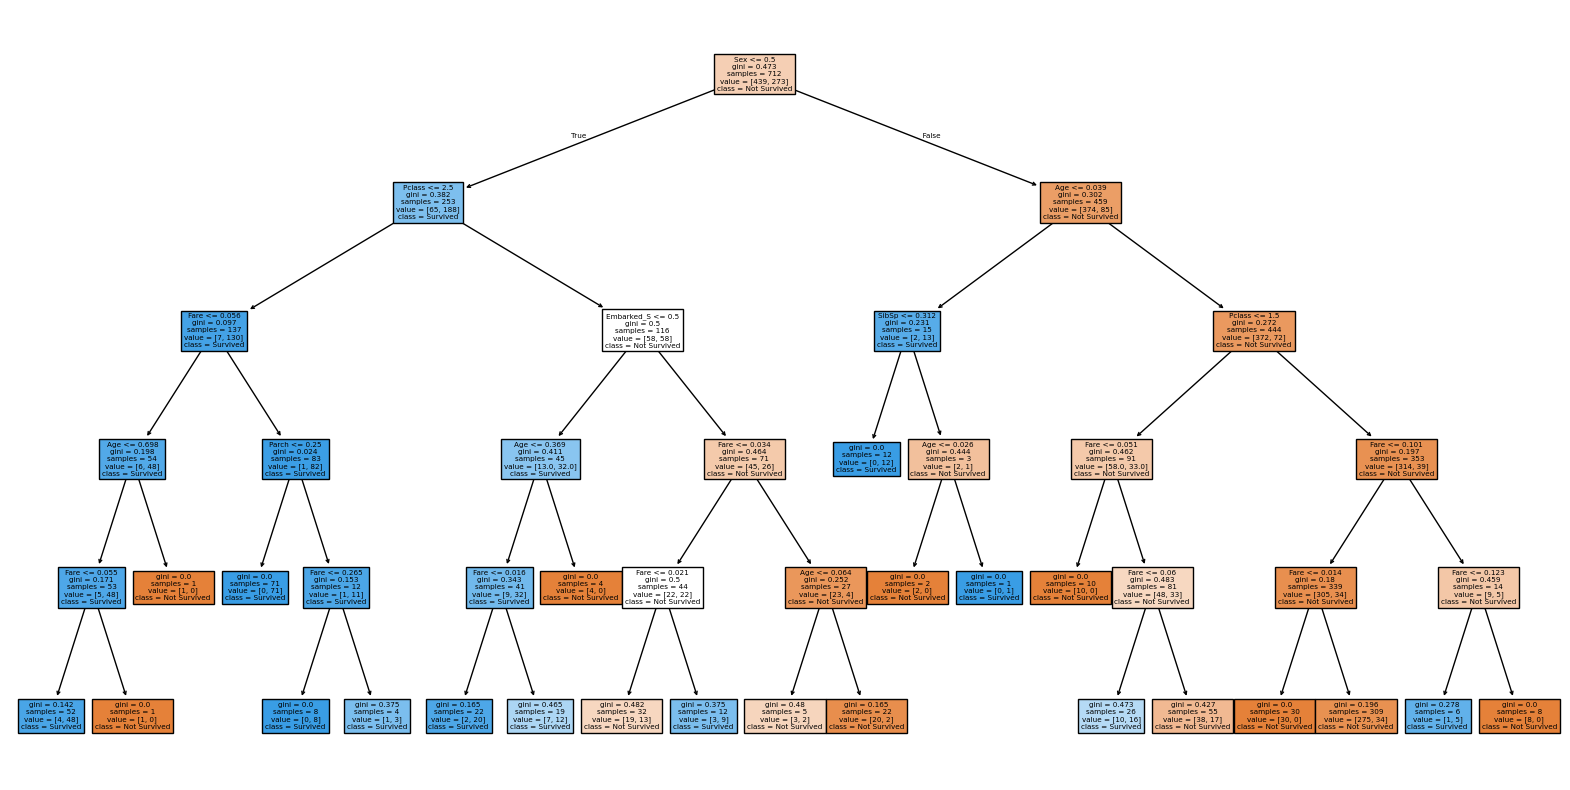

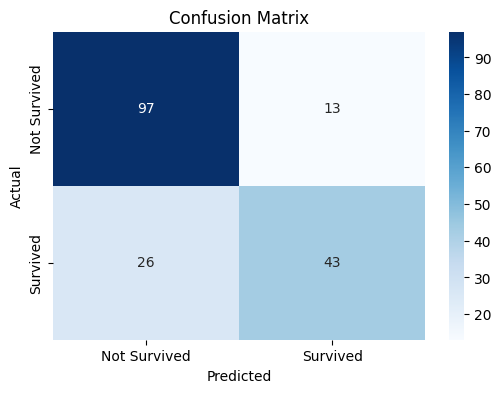


Model Evaluation Metrics:
Accuracy: 0.7821
Precision: 0.7679
Recall: 0.6232
F1-score: 0.6880

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.88      0.83       110
           1       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



In [3]:
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report

# Section 3: Data Preprocessing

# Q1: Load Dataset
try:
    df = pd.read_csv("/content/Titanic-Dataset.csv")
    print("Titanic dataset loaded successfully!")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")
    exit()

print("\nDataset shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())

# Q2: Select relevant features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
df = df[features + [target]]

# Q3: Handle missing values
# Impute Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)
# Impute Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Q4: Encode categorical variables
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # Male=1, Female=0
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Q5: Train-Test Split (80%-20%)
X = df.drop(target, axis=1)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTraining set size:", X_train.shape)
print("Testing set size:", X_test.shape)

# Q6: Normalize numerical features
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
scaler = MinMaxScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

# Section 4: Decision Tree Model

# Q7: Train Decision Tree
dt = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt.fit(X_train, y_train)

# Q8: Visualize the tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X_train.columns, class_names=['Not Survived','Survived'], filled=True)
plt.show()

# Q9: Confusion Matrix
y_pred = dt.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Survived','Survived'], yticklabels=['Not Survived','Survived'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Confusion Matrix")
plt.show()

# Q10: Evaluate Model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nModel Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Optional: Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
